# Functions needed for research

In [ ]:
from typing import Any, Union
from pathlib import Path
from IPython.display import display, Math, Latex
from scipy.spatial.transform import Rotation as R
import numpy as np
import matplotlib.pyplot as plt
import struct

CAMERA_MODELS = {
    0: ("SIMPLE_PINHOLE", 3), # f, cx, cy
    1: ("PINHOLE", 4),        # fx, fy, cx, cy (Undistortion 후 주로 사용됨)
    2: ("SIMPLE_RADIAL", 4),  # f, cx, cy, k
    3: ("RADIAL", 5),         # f, cx, cy, k1, k2
    4: ("OPENCV", 8),         # fx, fy, cx, cy, k1, k2, p1, p2 (기존 모델)
    5: ("OPENCV_FISHEYE", 8), 
    6: ("FULL_OPENCV", 12)
}

def readCamerasBin(file_path: str) -> dict[int, dict[str, Union[int, str, np.ndarray]]]:
    """
    Parameters
    ----------
    file_path: str

    Return
    ------
    cameras: dict[int, dict[str, Union[int, str, np.ndarray]]]
        For an integer `camera_id`, `cameras[camera_id]` is a dictionary containing the following keys:  
        cameras[camera_id]["model_name"]: str  
        cameras[camera_id]["model_id"]: int  
        cameras[camera_id]["width"]: int  
        cameras[camera_id]["height"]: int  
        cameras[camera_id]["params"]: np.ndarray of shape (num_params,)
    """
    cameras = {}
    with open(file_path, "rb") as fid:
        # 1. 카메라 개수 읽기
        num_cameras = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(num_cameras):
            # 2. Camera ID, Model ID
            camera_id = struct.unpack("<I", fid.read(4))[0]
            assert isinstance(camera_id, int), f"Camera ID should be an integer, got {type(camera_id)}"
            model_id = struct.unpack("<I", fid.read(4))[0]
            assert isinstance(model_id, int), f"Model ID should be an integer, got {type(model_id)}"

            # 3. Width, Height
            width = struct.unpack("<Q", fid.read(8))[0]
            height = struct.unpack("<Q", fid.read(8))[0]
            assert isinstance(width, int), f"Width should be an integer, got {type(width)}"
            assert isinstance(height, int), f"Height should be an integer, got {type(height)}"

            # 4. Model ID에 따라 파라미터 개수를 동적으로 결정
            if model_id not in CAMERA_MODELS:
                raise ValueError(f"지원하지 않는 카메라 모델 ID입니다: {model_id}")
            
            model_name, num_params = CAMERA_MODELS[model_id]
            assert isinstance(model_name, str), f"Model name should be a string, got {type(model_name)}"
            
            # 5. Parameters 읽기
            params = np.array(struct.unpack("<" + "d" * num_params, fid.read(8 * num_params)))
            
            cameras[camera_id] = {
                "model_name": model_name,
                "model_id": model_id,
                "width": width,
                "height": height,
                "params": params
            }
    return cameras

def readColmapImagesBin(file_path: str) -> dict[int, dict[str, Union[int, str, np.ndarray]]]:
    """
    Parameters
    ----------
    file_path: str

    Return
    ------
    images: dict[int, dict[str, Union[int, str, np.ndarray]]]
        For an integer `image_id`, `images[image_id]` is a dictionary containing the following keys:  
        images[image_id]["id"]: int  
        images[image_id]["name"]: str  
        images[image_id]["camera_id"]: int  
        images[image_id]["qvec"]: np.ndarray of shape (4,)  
        images[image_id]["tvec"]: np.ndarray of shape (3,)  
        images[image_id]["xys"]: np.ndarray of shape (num_points, 2)  
        images[image_id]["point3D_ids"]: np.ndarray of shape (num_points,)  
        images[image_id]["xys_valid"]: np.ndarray of shape (num_valid_points, 2)  
        images[image_id]["point3D_ids_valid"]: np.ndarray of shape (num_valid_points,) 
    """
    images = {}
    
    with open(file_path, "rb") as fid:
        # The first 8 bytes contain the total number of images
        numRegImages = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(numRegImages):
            # Read fixed-length camera pose and IDs (64 bytes total)
            # i = int (4 bytes), d = double (8 bytes)
            binaryImageProperties = struct.unpack("<idddddddi", fid.read(64))
            
            imageId = binaryImageProperties[0]
            qvec = np.array(binaryImageProperties[1:5])  # Quaternion (w, x, y, z)
            tvec = np.array(binaryImageProperties[5:8])  # Translation (x, y, z)
            cameraId = binaryImageProperties[8]
            
            # Read variable-length image name (stops at null byte \x00)
            imageName = b""
            char = fid.read(1)
            while char != b"\x00":
                imageName += char
                char = fid.read(1)
            imageName = imageName.decode("utf-8")
            
            # Read the number of 2D points for this specific image
            numPoints2D = struct.unpack("<Q", fid.read(8))[0]
            
            # Read 2D points: x (double), y (double), point3D_id (uint64/long long)
            # Each point is 24 bytes (8 + 8 + 8)
            x_y_id_s = struct.unpack("<" + "ddq" * numPoints2D, fid.read(24 * numPoints2D))
            
            # Reconstruct arrays for X,Y coordinates and their 3D point IDs
            if numPoints2D > 0:
                xys = np.column_stack([tuple(x_y_id_s[0::3]), tuple(x_y_id_s[1::3])])
                point3DIds = np.array(tuple(x_y_id_s[2::3]))
                valid_mask = point3DIds != -1
                xys_valid = xys[valid_mask]
                point3DIds_valid = point3DIds[valid_mask]
            else:
                xys = np.empty((0, 2), dtype=np.float64)
                point3DIds = np.empty(0, dtype=np.uint64)
            
            # Store cleanly in a dictionary
            images[imageId] = {
                "id": imageId,
                "name": imageName,
                "camera_id": cameraId,
                "qvec": qvec,
                "tvec": tvec,
                "xys": xys,
                "point3D_ids": point3DIds,
                "xys_valid": xys_valid,
                "point3D_ids_valid": point3DIds_valid
            }
            
    return images


def readColmapPoints3DBin(file_path: str) -> dict[int, dict[str, Union[int, np.ndarray]]]:
    """
    Parameters
    ----------
    file_path: str

    Return
    ------
    points3D: dict[int, dict[str, Union[int, str, np.ndarray]]]
        For an integer `points3D_id`, `points3D[points3D_id]` is a dictionary containing the following keys:  
        points3D[points3D_id]["id"]: int  
        points3D[points3D_id]["xyz"]: np.ndarray of shape (3,)  
        points3D[points3D_id]["rgb"]: np.ndarray of shape (3,)  
        points3D[points3D_id]["error"]: float  
        points3D[points3D_id]["track_length"]: int  
        points3D[points3D_id]["image_ids"]: np.ndarray of shape (track_length,)  
        points3D[points3D_id]["point2D_indices"]: np.ndarray of shape (track_length,)
    """
    points3D = {}
    
    with open(file_path, "rb") as fid:
        # 1. Read the total number of 3D points in the file (8 bytes)
        num_points = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(num_points):
            # 2. Read the fixed-length properties for one 3D point (51 bytes total)
            # Q = Point ID (8 bytes)
            # ddd = X, Y, Z coordinates (24 bytes)
            # BBB = R, G, B colors (3 bytes)
            # d = Reprojection error (8 bytes)
            # Q = Track length / number of images seeing this point (8 bytes)
            binaryData = fid.read(51)
            unpackedData = struct.unpack("<QdddBBBdQ", binaryData)
            
            point3D_id = unpackedData[0]
            xyz = np.array(unpackedData[1:4])       # The 3D position
            rgb = np.array(unpackedData[4:7])       # The color (0-255)
            error = unpackedData[7]                 # How accurate the point is
            trackLength = unpackedData[8]          # How many images see it
            
            # 3. Read the variable-length "Track" data
            # Each element in the track contains an Image ID (4 bytes) and a 2D Point Index (4 bytes)
            trackBytes = fid.read(8 * trackLength)
            
            if trackLength > 0:
                # Unpack all track integers at once using 'i' (4-byte integer)
                trackData = struct.unpack("<" + "ii" * trackLength, trackBytes)
                
                # Slice the tuple: evens are Image IDs, odds are Point2D Indexes
                imageIds = np.array(trackData[0::2])
                point2DIdxs = np.array(trackData[1::2])
            else:
                imageIds = np.array([], dtype=np.int32)
                point2DIdxs = np.array([], dtype=np.int32)
            
            # 4. Store everything cleanly in the dictionary
            points3D[point3D_id] = {
                "id": point3D_id,
                "xyz": xyz,
                "rgb": rgb,
                "error": error,
                "image_ids": imageIds,
                "point2D_idxs": point2DIdxs
            }
            
    return points3D

def quaternionToRotationMatrix(q: Union[list, np.ndarray]) -> np.ndarray:
    """
    Parameters
    ----------
    Input: q as a list or array of [w, x, y, z]
    
    Return
    ------
    Converts a normalized quaternion into a 3x3 rotation matrix.
    """
    # Normalize the quaternion to prevent distortion
    q = q / np.linalg.norm(q)

    # scipy uses the order [x, y, z, w], so we need to reorder
    q_Scipy = [q[1], q[2], q[3], q[0]]
    r_Matrix = R.from_quat(q_Scipy).as_matrix() # 3x3 회전 행렬 생성

    
    return r_Matrix

def linearTriangulation(poses, points_2d):
    """
    선형 삼각측량 (DLT)을 수행하여 3D 점을 복원합니다.
    
    :param poses: N개 카메라의 투영 행렬 [R | T] 리스트 (각 행렬의 크기는 3x4)
    :param points_2d: N개 이미지에서 매칭된 2D 정규화 좌표 (u, v) 리스트 (크기: Nx2)
    :return: 복원된 3D 점의 세계 좌표 (X, Y, Z) (크기: 3,)
    """
    A = []
    
    for i in range(len(poses)):
        P = poses[i]          # i번째 카메라의 3x4 투영 행렬
        u, v = points_2d[i]   # i번째 이미지의 정규화 2D 좌표
        
        # 행렬 A에 2개의 식을 추가 (행 벡터 추출)
        p1 = P[0, :]
        p2 = P[1, :]
        p3 = P[2, :]
        
        A.append(u * p3 - p1)
        A.append(v * p3 - p2)
        
    A = np.array(A) # 크기: (2N, 4)
    
    # SVD (특이값 분해) 수행
    _, _, Vh = np.linalg.svd(A)
    
    # Vh의 마지막 행이 AX = 0을 최소화하는 해 (동차 좌표계), A는 행렬, X는 점(x, y, z, 1)
    X_homo = Vh[-1, :]
    
    # 동차 좌표(Homogeneous)를 3D 직교 좌표로 변환 (W로 나누기)
    X_3d = X_homo[:3] / X_homo[3]
    
    return X_3d


# Running convert.py

We will run the following terminal command:

```cmd
python convert.py -s Gaussiatest/Test2
```

Here this command assumes there already have been input images in [`GaussianTest/Test2/input`](GaussianTest/Test2/input)

#### Check images:

In [2]:
inputdir = Path("GaussianTest/Test2/input")
for file in list(inputdir.iterdir()):
    print(file)

GaussianTest\Test2\input\0001.jpg
GaussianTest\Test2\input\0002.jpg
GaussianTest\Test2\input\0003.jpg
GaussianTest\Test2\input\0004.jpg
GaussianTest\Test2\input\0005.jpg
GaussianTest\Test2\input\0006.jpg
GaussianTest\Test2\input\0007.jpg
GaussianTest\Test2\input\0008.jpg
GaussianTest\Test2\input\0009.jpg
GaussianTest\Test2\input\0010.jpg
GaussianTest\Test2\input\0011.jpg
GaussianTest\Test2\input\0012.jpg
GaussianTest\Test2\input\0013.jpg
GaussianTest\Test2\input\0014.jpg
GaussianTest\Test2\input\0015.jpg
GaussianTest\Test2\input\0016.jpg
GaussianTest\Test2\input\0017.jpg
GaussianTest\Test2\input\0018.jpg
GaussianTest\Test2\input\0019.jpg
GaussianTest\Test2\input\0020.jpg
GaussianTest\Test2\input\0021.jpg
GaussianTest\Test2\input\0022.jpg
GaussianTest\Test2\input\0023.jpg
GaussianTest\Test2\input\0024.jpg
GaussianTest\Test2\input\0025.jpg
GaussianTest\Test2\input\0026.jpg
GaussianTest\Test2\input\0027.jpg
GaussianTest\Test2\input\0028.jpg


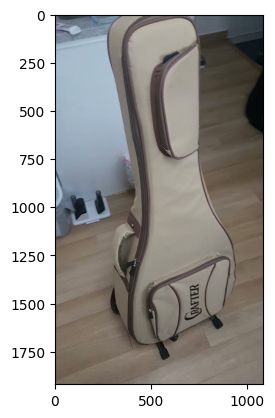

In [3]:
idx = 1 # Change it from 1 to 113
img = plt.imread(inputdir / f"{idx:04d}.jpg")
plt.imshow(img);


# Output Specifics

convert.py의 output은 중간에 COLMAP의 Mapper가 만드는 cameras, images, points3D.bin 파일들이 있고 이는

./GaussianTest/Test/distorted/sparse/0

위 경로에 저장된다.

그리고 Image Undistorter가 만드는 cameras, images, points3D.bin 파일들이 있는데 이는

./GaussianTest/Test/sparse/0

위 경로에 저장된다.

## cameras.bin 비교

### cameras.bin (After Mapper)

In [7]:
f_path = './GaussianTest/Test2/distorted/sparse/0/cameras.bin'
cameraDataDis = readCamerasBin(f_path)
print("model_name:", cameraDataDis[1]["model_name"], "\n")
# print("model_id: ")
# print(cameraDataDis[1]["model_id"], "\n")
print("width:", cameraDataDis[1]["width"], "\n")
print("height:", cameraDataDis[1]["height"], "\n")
print(f"params: len = {len(cameraDataDis[1]['params'])},")
print(f"        {cameraDataDis[1]['params']}")

model_name: OPENCV 

width: 1080 

height: 1920 

params: len = 8,
        [ 1.67379261e+03  1.67736649e+03  5.40000000e+02  9.60000000e+02
  4.64057485e-02 -3.86296505e-04 -9.84147047e-03  4.12674274e-03]


Mapper는 OPENCV라는 카메라 모델을 사용하였다.  
사용한 이미지의 width(가로 길이)가 1080, height(세로 길이)가 1920임을 알 수 있다.  

카메라의 파라미터로는 순서대로  
Focal Length를 나타내는 $f_x, f_y$  
Principal Point를 나타내는 $c_x, c_y$  
Radial Distortion을 나타내는 $k_1, k_2$  
Tangential Distortion을 나타내는 $p_1, p_2$  
가 있다.

In [8]:
#이런 식으로 표시할 수도 있음
fx, fy= cameraDataDis[1]['params'][0:2]
cx, cy= cameraDataDis[1]['params'][2:4]
k1, k2= cameraDataDis[1]['params'][4:6]
p1, p2= cameraDataDis[1]['params'][6:8]

print("Focal Length:")
display(Math(fr"f_x = {fx},\, f_y = {fy}"))
print("Principal Point:")
display(Math(fr"c_x = {cx},\, c_y = {cy}"))
print("Radial Distortion:")
display(Math(fr"k_1 = {k1},\, k_2 = {k2}"))
print("Tangential Distortion:")
display(Math(fr"p_1 = {p1},\, p_2 = {p2}"))

Focal Length:


<IPython.core.display.Math object>

Principal Point:


<IPython.core.display.Math object>

Radial Distortion:


<IPython.core.display.Math object>

Tangential Distortion:


<IPython.core.display.Math object>

### cameras.bin (After Image Undistorter)

In [9]:
f_path = './GaussianTest/Test2/sparse/0/cameras.bin'
cameraDataUndis = readCamerasBin(f_path)
print("model_name:", cameraDataUndis[1]["model_name"], "\n")
# print("model_id: ")
# print(cameraData[1]["model_id"], "\n")
print("width:", cameraDataUndis[1]["width"], "\n")
print("height:", cameraDataUndis[1]["height"], "\n")
print("params:", cameraDataUndis[1]["params"], "\n")

model_name: PINHOLE 

width: 1041 

height: 1846 

params: [1673.79261224 1677.36648841  520.5         923.        ] 



Image Undistorter는 PINHOLE이라는 카메라 모델을 쓴다.  
왜곡이 보정되어 width와 height의 값이 달라진 것을 확인할 수 있다.  

카메라 파라미터로 순서대로  
Focal Length를 나타내는 $f_x, f_y$  
Principal Point를 나타내는 $c_x, c_y$  
가 있는데 이는 왜곡을 보정한 뒤이므로 왜곡을 저장했던 파라미터들이 사라졌기 때문이다.

In [10]:
fx, fy= cameraDataUndis[1]['params'][0:2]
cx, cy= cameraDataUndis[1]['params'][2:4]

print("Focal Length:")
display(Math(fr"f_x = {fx},\, f_y = {fy}"))
print("Principal Point:")
display(Math(fr"c_x = {cx},\, c_y = {cy}"))

Focal Length:


<IPython.core.display.Math object>

Principal Point:


<IPython.core.display.Math object>

### "After Mapper" vs. "After Image Undistorter" 비교

In [11]:
print(f"Focal Length same?: {cameraDataDis[1]['params'][0:2] - cameraDataUndis[1]['params'][0:2]}")
print("Principal points")
print("\tDis:   ", cameraDataDis[1]['params'][2:4])
print("\tUndis: ", cameraDataUndis[1]['params'][2:4])

Focal Length same?: [0. 0.]
Principal points
	Dis:    [540. 960.]
	Undis:  [520.5 923. ]


### 사진 비교

위 사진(input)의 width가 아래 사진(After Undistortion)보다 큰 것을 볼 수 있다.

Text(0.5, 1.0, 'Undistorted Image')

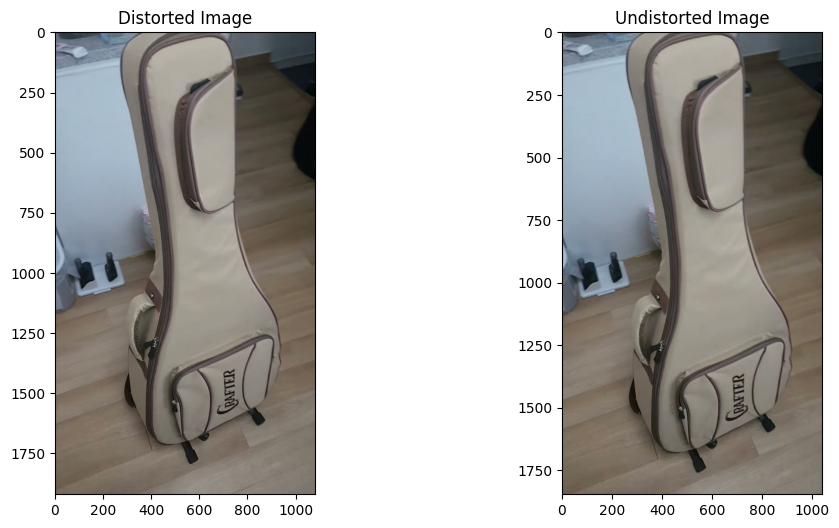

In [12]:
inputdir_base = Path("GaussianTest/Test2")
idx = 1 # Change it from 1 to 28
imgDir = plt.imread(inputdir_base / f"input/{idx:04d}.jpg")
imgUndir = plt.imread(inputdir_base / f"images/{idx:04d}.jpg")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(imgDir)
axes[0].set_title("Distorted Image")
axes[1].imshow(imgUndir)
axes[1].set_title("Undistorted Image")

## images.bin 비교

#### How to get data:  

f_path = './GaussianTest/Test2/distorted/sparse/0/images.bin' (DO NOT CHANGE)  
imgData = readColmapImagesBin(f_path)  
  
Example: Print data for the first image  
first_image_id = list(imgData.keys())[0]  
print(imgData[first_image_id]['name'])  
print(imgData[first_image_id]['qvec'])

### images.bin 내용(After Mapper)
`images.bin` 파일 내의 정보가 아래 셀의 `imgData: dict` 변수에 담겨 있다.

In [64]:
f_path = './GaussianTest/Test2/distorted/sparse/0/images.bin'
imgDataDis = readColmapImagesBin(f_path)
print(f"{type(imgDataDis) = }")
print(f"{imgDataDis.keys() = }")
imgId = list(imgDataDis.keys())[0]

type(imgDataDis) = <class 'dict'>
imgDataDis.keys() = dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])


각 key `imgId: int`에 대해, `imgDataDis[imgId]`는 또 다시 dictionary로, 아래와 같은 정보를 포함하고 있다

In [25]:
#print the data of the image
# print("name: ", imgData[imgId]['name'])
print(f"{imgDataDis[imgId].keys() = }")

print(f"{imgDataDis[imgId]['name'] = }")
print(f"{imgDataDis[imgId]['camera_id'] = }")
print(f"{imgDataDis[imgId]['qvec'] = }")
print(f"{imgDataDis[imgId]['tvec'] = }")

imgDataDis[imgId].keys() = dict_keys(['id', 'name', 'camera_id', 'qvec', 'tvec', 'xys', 'point3D_ids', 'xys_valid', 'point3D_ids_valid'])
imgDataDis[imgId]['name'] = '0001.jpg'
imgDataDis[imgId]['camera_id'] = 1
imgDataDis[imgId]['qvec'] = array([ 0.98821532, -0.00190512,  0.07622084,  0.13272993])
imgDataDis[imgId]['tvec'] = array([-0.21135841, -3.46193705,  2.75338573])


In [26]:
print(f"# imgDataDis[imgId]['xys']")
print(f"\t{type(imgDataDis[imgId]['xys']) = }")
print(f"\t{imgDataDis[imgId]['xys'].shape = }: (Number of feature points, 2D pixel position)")
print(imgDataDis[imgId]['xys'], "\n")
# print("Number of feature points: ", len(imgDataDis[imgId]['xys']), "\n")

print(f"# imgDataDis[imgId]['xys_valid']")
print(f"\t{type(imgDataDis[imgId]['xys_valid']) = }")
print(f"\t{imgDataDis[imgId]['xys_valid'].shape = }: (Number of valid feature points)")
print(imgDataDis[imgId]['xys_valid'], "\n")

# imgDataDis[imgId]['xys']
	type(imgDataDis[imgId]['xys']) = <class 'numpy.ndarray'>
	imgDataDis[imgId]['xys'].shape = (2115, 2): (Number of feature points, 2D pixel position)
[[ 191.53845215   15.9071579 ]
 [ 723.39367676   57.0906868 ]
 [ 129.11950684   92.3783493 ]
 ...
 [ 183.76550293 1325.32751465]
 [ 654.31970215  938.73620605]
 [ 654.31970215  938.73620605]] 

# imgDataDis[imgId]['xys_valid']
	type(imgDataDis[imgId]['xys_valid']) = <class 'numpy.ndarray'>
	imgDataDis[imgId]['xys_valid'].shape = (128, 2): (Number of valid feature points)
[[ 374.27313232 1150.60131836]
 [ 902.2354126  1273.39050293]
 [ 488.86016846 1538.84643555]
 [ 399.88531494 1726.20605469]
 [ 404.23526001 1743.4675293 ]
 [ 561.78759766  691.21020508]
 [ 370.54302979 1148.4432373 ]
 [ 355.24484253 1150.22924805]
 [ 366.66088867 1155.25537109]
 [ 410.4630127  1309.68371582]
 [ 352.36776733 1340.71716309]
 [ 702.89477539 1438.19226074]
 [ 502.30285645 1524.94213867]
 [ 502.30285645 1524.94213867]
 [ 505.78826904 

In [27]:
print("# point3D_ids")
point3D_ids = imgDataDis[imgId]['point3D_ids']
print(f"\t{type(point3D_ids) = }")
print(f"\t{point3D_ids.shape = }: (Number of 3D points)")
print(point3D_ids, "\n")

print("# point3D_ids_valid")
point3D_ids_valid = imgDataDis[imgId]['point3D_ids_valid']
print(f"\t{type(point3D_ids_valid) = }")
print(f"\t{point3D_ids_valid.shape = }: (Number of valid 3D points)")
print(point3D_ids_valid, "\n")

# point3D_ids
	type(point3D_ids) = <class 'numpy.ndarray'>
	point3D_ids.shape = (2115,): (Number of 3D points)
[-1 -1 -1 ... -1 -1 -1] 

# point3D_ids_valid
	type(point3D_ids_valid) = <class 'numpy.ndarray'>
	point3D_ids_valid.shape = (128,): (Number of valid 3D points)
[1769 1700 1755  653 1709 1756 1767 1771 1527  636 1528 1418 1707 1706
 1701 1708 1759 1702 1715  667 1548 1776 1537 1535 1419 1539 1417 1760
 1546 1879 1761 1428 1569 1567 1717 1451 1638 1718 1459 1453 1574 1573
 1488 1404 1719 1792 1547 1773 1775 1774 1722 1427 1678 1585 1452 1436
 1437 1724 1723 1763 1456 1460 1449 1458 1439 1480 1540 1725 1803 1726
 1791  363 1770 1467 1654 1474 1475 1730 1476 1477 1448 1484  684 1764
 1438 1765 1731 1766 1469 1592 1492 1597 1478 1600 1598 1737 1738 1503
 1607 1772 1740 1739  516  390 1742 1505 1814 1861  415 1609 1743 1612
 1744 1817 1820 1819 1509 1510 1747 1511 1512 1768 1748 1615 1613 1823
 1749 1750] 



위에서 본 것과 같이 1번 이미지에 대해서는 2115개의 특징점이 나왔지만 이중 valid한 즉 실제로 쓰이는 점은 128개의 특징점이다. 

In [28]:
np.where(point3D_ids != -1)

(array([ 141,  222,  350,  450,  454,  504,  580,  581,  583,  670,  682,
         726,  752,  753,  759,  761,  763,  764,  797,  939,  978,  984,
         992, 1046, 1086, 1102, 1109, 1114, 1278, 1282, 1288, 1324, 1335,
        1344, 1345, 1352, 1354, 1355, 1358, 1365, 1371, 1372, 1376, 1398,
        1401, 1535, 1543, 1544, 1546, 1547, 1564, 1573, 1575, 1597, 1599,
        1604, 1605, 1607, 1608, 1609, 1611, 1612, 1615, 1617, 1618, 1620,
        1628, 1630, 1697, 1706, 1712, 1713, 1722, 1723, 1724, 1740, 1741,
        1745, 1753, 1754, 1755, 1757, 1760, 1765, 1777, 1802, 1823, 1828,
        1832, 1837, 1840, 1843, 1848, 1852, 1855, 1886, 1907, 1929, 1949,
        1952, 1953, 1983, 1985, 1987, 1994, 1997, 2006, 2009, 2011, 2013,
        2015, 2019, 2026, 2027, 2045, 2046, 2054, 2056, 2057, 2063, 2064,
        2077, 2081, 2083, 2087, 2090, 2091, 2103]),)

In [29]:
point3D_ids[141]

np.int64(1769)

TODO: 이 1769가 최초로 초기화하는 Gaussian 덩어리의 인덱스가 맞는지 확인해보기
* 코드 상에 해당 위치를 찾거나
* colmap 돌리면서 feature matching 정보가 있을 건데, 가령 "0번째 이미지의 141번에 피처가 3번째이미지의 100번째 피처랑 대응이 됐다"라면
  * imgData[0]['point3D_ids'][141] == imgData[3]['point3D_ids'][100]

### images.bin 내용(After Image Undistortion)

In [30]:
f_path = './GaussianTest/Test2/sparse/0/images.bin'
imgDataUndis = readColmapImagesBin(f_path)
print(f"{type(imgDataUndis) = }")
print(f"{imgDataUndis.keys() = }")
print(f"{len(imgDataDis.keys()) = }")
imgId = list(imgDataUndis.keys())[0]

type(imgDataUndis) = <class 'dict'>
imgDataUndis.keys() = dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])
len(imgDataDis.keys()) = 25


In [31]:
#print the data of the image
# print("name: ", imgDataUndis[imgId]['name'])
print(f"{imgDataUndis[imgId].keys() = }")

print(f"{imgDataUndis[imgId]['name'] = }")
print(f"{imgDataUndis[imgId]['camera_id'] = }")
print(f"{imgDataUndis[imgId]['qvec'] = }")
print(f"{imgDataUndis[imgId]['tvec'] = }")

imgDataUndis[imgId].keys() = dict_keys(['id', 'name', 'camera_id', 'qvec', 'tvec', 'xys', 'point3D_ids', 'xys_valid', 'point3D_ids_valid'])
imgDataUndis[imgId]['name'] = '0001.jpg'
imgDataUndis[imgId]['camera_id'] = 1
imgDataUndis[imgId]['qvec'] = array([ 0.98821532, -0.00190512,  0.07622084,  0.13272993])
imgDataUndis[imgId]['tvec'] = array([-0.21135841, -3.46193705,  2.75338573])


In [32]:
print(f"# imgDataUndis[imgId]['xys']")
print(f"\t{type(imgDataUndis[imgId]['xys']) = }")
print(f"\t{imgDataUndis[imgId]['xys'].shape = }: (Number of feature points, 2D pixel position)")
print(imgDataUndis[imgId]['xys'], "\n")
# print("Number of feature points: ", len(imgDataUndis[imgId]['xys']), "\n")

print(f"# imgDataUndis[imgId]['xys_valid']")
print(f"\t{type(imgDataUndis[imgId]['xys_valid']) = }")
print(f"\t{imgDataUndis[imgId]['xys_valid'].shape = }: (Number of valid feature points)")
print(imgDataUndis[imgId]['xys_valid'], "\n")

# imgDataUndis[imgId]['xys']
	type(imgDataUndis[imgId]['xys']) = <class 'numpy.ndarray'>
	imgDataUndis[imgId]['xys'].shape = (2115, 2): (Number of feature points, 2D pixel position)
[[ 178.17584732    7.21783012]
 [ 697.61872921   46.12435468]
 [ 116.48467186   79.34114548]
 ...
 [ 162.99888681 1290.51032121]
 [ 634.66835044  901.8375305 ]
 [ 634.66835044  901.8375305 ]] 

# imgDataUndis[imgId]['xys_valid']
	type(imgDataUndis[imgId]['xys_valid']) = <class 'numpy.ndarray'>
	imgDataUndis[imgId]['xys_valid'].shape = (128, 2): (Number of valid feature points)
[[ 354.28205816 1114.36240543]
 [ 881.49408031 1237.1475943 ]
 [ 468.44665764 1504.69837055]
 [ 378.93204532 1692.52713659]
 [ 383.25055344 1709.74407535]
 [ 542.01596312  655.81440758]
 [ 350.54580297 1112.19988056]
 [ 335.20280373 1114.02482794]
 [ 346.64019783 1119.05571503]
 [ 390.29926091 1274.36846852]
 [ 331.96474287 1305.71121725]
 [ 682.86133913 1402.98655168]
 [ 481.94951077 1490.70279313]
 [ 481.94951077 1490.70279313]
 [ 4

In [33]:
print("# point3D_ids")
point3D_ids = imgDataUndis[imgId]['point3D_ids']
print(f"\t{type(point3D_ids) = }")
print(f"\t{point3D_ids.shape = }: (Number of 3D points)")
print(point3D_ids, "\n")

print("# point3D_ids_valid")
point3D_ids_valid = imgDataUndis[imgId]['point3D_ids_valid']
print(f"\t{type(point3D_ids_valid) = }")
print(f"\t{point3D_ids_valid.shape = }: (Number of valid 3D points)")
print(point3D_ids_valid, "\n")

# point3D_ids
	type(point3D_ids) = <class 'numpy.ndarray'>
	point3D_ids.shape = (2115,): (Number of 3D points)
[-1 -1 -1 ... -1 -1 -1] 

# point3D_ids_valid
	type(point3D_ids_valid) = <class 'numpy.ndarray'>
	point3D_ids_valid.shape = (128,): (Number of valid 3D points)
[1769 1700 1755  653 1709 1756 1767 1771 1527  636 1528 1418 1707 1706
 1701 1708 1759 1702 1715  667 1548 1776 1537 1535 1419 1539 1417 1760
 1546 1879 1761 1428 1569 1567 1717 1451 1638 1718 1459 1453 1574 1573
 1488 1404 1719 1792 1547 1773 1775 1774 1722 1427 1678 1585 1452 1436
 1437 1724 1723 1763 1456 1460 1449 1458 1439 1480 1540 1725 1803 1726
 1791  363 1770 1467 1654 1474 1475 1730 1476 1477 1448 1484  684 1764
 1438 1765 1731 1766 1469 1592 1492 1597 1478 1600 1598 1737 1738 1503
 1607 1772 1740 1739  516  390 1742 1505 1814 1861  415 1609 1743 1612
 1744 1817 1820 1819 1509 1510 1747 1511 1512 1768 1748 1615 1613 1823
 1749 1750] 



### 분석

images.bin 파일은 처음 8byte에 전체 이미지 개수를 나타내는 Header가 있다.  
Header(8bytes): 전체 이미지 개수  

그 후 각 이미지당 다음과 같은 데이터를 가진다.
처음에 이미지 데이터 블록이 있는데, 이미지의 고정 속성을 나타낸다.  
**Image Data Block(64 bytes): imageId(int 1개) + qvec(double 3개) + tvec(double 3개) + cameraId(int 1개)**

그리고 이미지 파일 이름이 있다.  
**imageName(changeable)**

그 후 2D 포인트의 개수가 저장되어 있고,  
**numPoints2D(8bytes, double)**

마지막으로 특징점 리스트가 있는데 이는 특징점 개수에 따라 달라진다. 각 데이터는 24 bytes의 크기를 가진다. 이미지 왼쪽 상단 꼭짓점을 기준으로 2차원 좌표계를 만들어 표현한다.(x 좌표는 오른쪽으로 y 좌표는 아래로 +)    
**xys + points3D: x-coord(8bytes, double) + y-coord(8bytes, double) + points3D(8bytes, long long int)**  

두 images.bin의 xys의 결과가 다른 것은 왜곡 보정이 있었기 때문이다.

TODO: 어느 FIELD는 변화가 없고 어느 field는 바뀌었는지, 코드상에서 비교 실행코드 (jupyter 튜토리얼 코드가 짧되 확신을 주는 것이 best)

## points3D.bin 비교

#### How to get data(ex.)

file_path = './GaussianTest/Test/sparse/0/points3D.bin'  
points_data = read_colmap_points3D_bin(file_path)  
  
Example: Get the XYZ coordinate of the first point in the dictionary  
first_point_id = list(points_data.keys())[0]  
print("XYZ:", points_data[first_point_id]['xyz'])  
print("RGB:", points_data[first_point_id]['rgb'])

### points3D.bin 내용(After Mapper)
"Key"가 몇개인가 출력하고, 그 인덱스가 위 image.bin의 point3Did랑 어떻게 매핑이 되는지, 
e.g. imgData[141]['xys']에 z값을 붙여서, camera matrix 어떻게 잘 곱하면 pts3DData[1769].xyz가 재현이 되는지 확인

이런 느낌으로, 이전에 확인했던 값으로부터 유도되는 값이 있는지 매번 체크

In [14]:
f_path = './GaussianTest/Test2/distorted/sparse/0/points3D.bin'
pts3DDataDis = readColmapPoints3DBin(f_path)
print(f"{type(pts3DDataDis) = }")
print(f"{pts3DDataDis.keys() = }")
print(f"{len(pts3DDataDis.keys()) = }")
point3DId = list(pts3DDataDis.keys())[0]

type(pts3DDataDis) = <class 'dict'>
pts3DDataDis.keys() = dict_keys([1, 944, 393, 1054, 2, 3, 1064, 387, 1463, 4, 5, 948, 1066, 397, 1457, 6, 7, 8, 9, 952, 1126, 401, 10, 11, 1072, 395, 1471, 12, 13, 956, 1074, 405, 1465, 14, 15, 1132, 415, 16, 17, 896, 1134, 409, 18, 19, 1080, 403, 1415, 20, 21, 900, 1082, 413, 1409, 22, 23, 1140, 487, 24, 25, 904, 26, 27, 1024, 411, 1423, 28, 29, 908, 1026, 485, 1417, 30, 31, 32, 33, 848, 425, 728, 1086, 34, 1874, 35, 1746, 419, 1367, 36, 1735, 37, 852, 429, 732, 1728, 1361, 38, 39, 439, 1028, 40, 41, 856, 433, 1030, 42, 43, 427, 1375, 44, 1743, 45, 860, 437, 1736, 46, 48, 49, 928, 441, 1038, 50, 51, 435, 1447, 52, 1751, 53, 932, 445, 1744, 54, 55, 391, 1044, 56, 57, 936, 385, 1046, 58, 59, 1056, 443, 1455, 60, 1759, 61, 940, 1058, 389, 1449, 62, 63, 1837, 1116, 463, 64, 65, 1008, 1118, 457, 66, 67, 451, 1527, 68, 69, 1012, 461, 1521, 70, 71, 1845, 1188, 471, 72, 73, 1016, 1190, 465, 74, 75, 459, 1535, 76, 77, 1020, 469, 1529, 78, 79, 1853, 1196, 479

각 key `point3DId: int`에 대해, `pts3DDataDis[point3DId]]`는 또 다시 dictionary로, 아래와 같은 정보를 포함하고 있다

In [15]:
#print the data of the point3Ds
print(f"{pts3DDataDis[point3DId].keys() = }")

print(f"{pts3DDataDis[point3DId]['id'] = }")
print(f"{pts3DDataDis[point3DId]['xyz'] = }")
print(f"{pts3DDataDis[point3DId]['rgb'] = }")
print(f"{pts3DDataDis[point3DId]['error'] = }")
print(f"{pts3DDataDis[point3DId]['image_ids'] = }")
print(f"{pts3DDataDis[point3DId]['point2D_idxs'] = }")

pts3DDataDis[point3DId].keys() = dict_keys(['id', 'xyz', 'rgb', 'error', 'image_ids', 'point2D_idxs'])
pts3DDataDis[point3DId]['id'] = 1
pts3DDataDis[point3DId]['xyz'] = array([ 4.34101526, -1.97590981,  8.94548552])
pts3DDataDis[point3DId]['rgb'] = array([103, 100, 107])
pts3DDataDis[point3DId]['error'] = 0.619442107834998
pts3DDataDis[point3DId]['image_ids'] = array([27, 23])
pts3DDataDis[point3DId]['point2D_idxs'] = array([ 207, 1079])


### points3D.bin 내용(After Image Undistortion)

"Key"가 몇개인가 출력

In [16]:
f_path = './GaussianTest/Test2/sparse/0/points3D.bin'
pts3DDataUndis = readColmapPoints3DBin(f_path)
print(f"{type(pts3DDataUndis) = }")
print(f"{pts3DDataUndis.keys() = }")
print(f"Number of 3D points: {len(pts3DDataUndis.keys())}")

type(pts3DDataUndis) = <class 'dict'>
pts3DDataUndis.keys() = dict_keys([1, 944, 2, 393, 1054, 3, 1064, 387, 4, 1463, 948, 5, 397, 1066, 6, 1457, 7, 8, 952, 9, 401, 1126, 10, 11, 395, 1072, 12, 1471, 956, 13, 405, 1074, 14, 1465, 15, 415, 1132, 16, 896, 17, 409, 1134, 18, 19, 403, 1080, 20, 1415, 900, 21, 413, 1082, 22, 1409, 23, 487, 1140, 24, 904, 25, 26, 27, 1423, 28, 411, 1024, 29, 908, 1417, 30, 1026, 485, 31, 32, 33, 848, 34, 425, 728, 1086, 1874, 35, 1367, 36, 1746, 419, 1735, 37, 852, 1728, 1361, 38, 429, 732, 39, 40, 439, 1028, 41, 856, 42, 433, 1030, 43, 1375, 44, 427, 1743, 45, 860, 1736, 46, 437, 48, 49, 928, 50, 441, 1038, 51, 1447, 52, 435, 1751, 53, 932, 1744, 54, 445, 55, 56, 391, 1044, 57, 936, 58, 385, 1046, 59, 1455, 60, 1056, 443, 1759, 61, 940, 1449, 62, 1058, 389, 63, 64, 1837, 1116, 463, 65, 1008, 66, 1118, 457, 67, 1527, 68, 451, 69, 1012, 1521, 70, 461, 71, 72, 1845, 1188, 471, 73, 1016, 74, 1190, 465, 75, 1535, 76, 459, 77, 1020, 1529, 78, 469, 79, 80, 801, 18

In [17]:
pts3DDataUndis_id=list(pts3DDataUndis.keys())
np.where(np.array(pts3DDataUndis_id) == 1769)

(array([1174]),)

In [73]:
#print the data of the point3Ds
point3DId = list(pts3DDataUndis.keys())[0]
print(f"{pts3DDataUndis[point3DId].keys() = }")

print(f"{pts3DDataUndis[point3DId]['id'] = }")
print(f"{pts3DDataUndis[point3DId]['xyz'] = }")
print(f"{pts3DDataUndis[point3DId]['rgb'] = }")
print(f"{pts3DDataUndis[point3DId]['error'] = }")
print(f"{pts3DDataUndis[point3DId]['image_ids'] = }")
print(f"{pts3DDataUndis[point3DId]['point2D_idxs'] = }")

pts3DDataUndis[point3DId].keys() = dict_keys(['id', 'xyz', 'rgb', 'error', 'image_ids', 'point2D_idxs'])
pts3DDataUndis[point3DId]['id'] = 1
pts3DDataUndis[point3DId]['xyz'] = array([ 4.34101526, -1.97590981,  8.94548552])
pts3DDataUndis[point3DId]['rgb'] = array([103, 100, 107])
pts3DDataUndis[point3DId]['error'] = 0.619442107834998
pts3DDataUndis[point3DId]['image_ids'] = array([27, 23])
pts3DDataUndis[point3DId]['point2D_idxs'] = array([ 207, 1079])


### 분석

point3D.bin 파일은 images.bin 파일과 마찬가지로 가장 처음 8byte에 이미지의 총 개수가 저장되어 있다.  
Header(8bytes): 전체 이미지 개수  

하나의 3D 포인트는 총 51bytes의 데이터로 이루어져 있고 아래 순서대로 데이터가 저장된다.  
Point ID (8 bytes, long long int)  
X, Y, Z coordinates (24 bytes, double)  
R, G, B colors (3 bytes, 8-bit-unsigned char)  
Reprojection Error (8 bytes, double)  
Track Length: 해당 점을 관측한 이미지의 개수(8 bytes, long long int)

이 뒤에 Track Byte 데이터가 저장되어 있는데 이는 (8*Track Length) byte에 해당하는 크기를 가진다.
(imageId, point2D_idx) 형태의 튜플로 데이터가 저장되어 있다.  
imageId(4bytes, int)
point2D_idx(4bytes, int)  

위 결과를 예시로 들면 __("point3DId = list(pts3DData.keys())[0]")__  
1번 3D point는 27번 사진의 207번 점과 23번 사진의 1079번 점이 교차하여 생성된 3D 점인 것을 알 수 있다.

# Intro

Undistortion 후의 images.bin 파일의 `name: 0001.jpg`의 첫 번째 valid한 point3D_id는 1769이다. 이에 대해 images.bin의 point3D_id가 point3D.bin의 어떤 값과 관련이 있는지 알아보려 한다.

In [67]:
np.where(point3D_ids != -1)

(array([ 141,  222,  350,  450,  454,  504,  580,  581,  583,  670,  682,
         726,  752,  753,  759,  761,  763,  764,  797,  939,  978,  984,
         992, 1046, 1086, 1102, 1109, 1114, 1278, 1282, 1288, 1324, 1335,
        1344, 1345, 1352, 1354, 1355, 1358, 1365, 1371, 1372, 1376, 1398,
        1401, 1535, 1543, 1544, 1546, 1547, 1564, 1573, 1575, 1597, 1599,
        1604, 1605, 1607, 1608, 1609, 1611, 1612, 1615, 1617, 1618, 1620,
        1628, 1630, 1697, 1706, 1712, 1713, 1722, 1723, 1724, 1740, 1741,
        1745, 1753, 1754, 1755, 1757, 1760, 1765, 1777, 1802, 1823, 1828,
        1832, 1837, 1840, 1843, 1848, 1852, 1855, 1886, 1907, 1929, 1949,
        1952, 1953, 1983, 1985, 1987, 1994, 1997, 2006, 2009, 2011, 2013,
        2015, 2019, 2026, 2027, 2045, 2046, 2054, 2056, 2057, 2063, 2064,
        2077, 2081, 2083, 2087, 2090, 2091, 2103]),)

In [68]:
point3D_ids[141]

np.int64(1769)

In [19]:
pts3DDataUndis_id=list(pts3DDataUndis.keys())
print(np.where(np.array(pts3DDataUndis_id) == 1769))

(array([1174]),)


In [20]:
point3DId = list(pts3DDataUndis.keys())[1174]
print(f"{pts3DDataUndis[point3DId]['image_ids'] = }")
print(f"{pts3DDataUndis[point3DId]['point2D_idxs'] = }")

pts3DDataUndis[point3DId]['image_ids'] = array([28,  1,  4,  2])
pts3DDataUndis[point3DId]['point2D_idxs'] = array([4122,  141,  325,  890])


# images.bin point3D_id 값, point3D.bin (image_ids, point2D_idxs) 비교

그 인덱스가 위 image.bin의 point3Did랑 어떻게 매핑이 되는지, 
e.g. imgData[141]['xys']에 z값을 붙여서, camera matrix 어떻게 잘 곱하면 pts3DData[1769].xyz가 재현이 되는지 확인

이런 느낌으로, 이전에 확인했던 값으로부터 유도되는 값이 있는지 매번 체크

imgages.bin 파일에 들어있는 point3D_ids는 해당 image에서 뽑아낸 특징점들이 어떤 point3D로 매핑되는지가 저장되어 있다.
  
`ex)`  
images.bin 파일 0001.jpg의 141번째 특징점의 point3D_id: 1769  
라고 하면  
point3D.bin의 point3DId == 1769를 Mapping하는데 필요했던 점 중에 하나가 0001.jpg의 141번째 특징점이다.

**주의**  
`point3DId == 1769라는 것은 점의 'id'값이 1769라는거지 1769번째 3D Point가 아니다.`

In [37]:
keyDict = {}
print(f"{imgDataUndis.keys() = }")
print(f"point3D Mapped: {pts3DDataUndis[point3DId]['id']}")
for key in imgDataUndis.keys():
    n=len(imgDataUndis[key]['point3D_ids'])
    for j in range(n):  
        if imgDataUndis[key]['point3D_ids'][j]==pts3DDataUndis[point3DId]['id']:
            print(f"{imgDataUndis[key]['name']}, {j}th ")
            keyDict[key] = j

imgDataUndis.keys() = dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])
point3D Mapped: 1769
0001.jpg, 141th 
0002.jpg, 890th 
0004.jpg, 325th 
0028.jpg, 4122th 


해당하는 `feature point`들의 좌표

In [38]:
print(keyDict)
for key,value in keyDict.items():
    print(f"Image: {key}, Index: {value}, Coordinates: {imgDataUndis[key]['xys'][value]}")

{1: 141, 2: 890, 4: 325, 28: 4122}
Image: 1, Index: 141, Coordinates: [ 354.28205816 1114.36240543]
Image: 2, Index: 890, Coordinates: [ 429.78520556 1122.5532335 ]
Image: 4, Index: 325, Coordinates: [ 443.00325037 1004.49354087]
Image: 28, Index: 4122, Coordinates: [ 276.47013621 1303.1033788 ]


2차원 좌표(x,y)를 `keyDictNorm(u,v,1)`(Ray의 direction 찾기에 쓰임) `keyDictNorm2D(u,v)`(Linear Triangulation에 사용)로 정규화  
$$u=\frac{x-c_x}{f_x},\quad v=\frac{y-c_y}{f_y}$$

In [39]:
keyDictNorm = {}
keyDictNorm2D= {}
print(f"{fx=}, {fy=}, {cx=}, {cy=}")
for key, value in keyDict.items():
    x, y = imgDataUndis[key]['xys'][value]
    # Normalize the coordinates using the camera parameters
    x_norm = (x - cx) /fx
    y_norm = (y - cy) /fy
    keyDictNorm[key] = np.array([x_norm, y_norm, 1])
    keyDictNorm2D[key] = np.array([x_norm, y_norm])
for key, value in keyDictNorm.items():
    print(f"Image: {key}, Normalized Coordinates: {value}")
for key, value in keyDictNorm2D.items():
    print(f"Image: {key}, Normalized Coordinates: {value}")    

fx=np.float64(1673.7926122386516), fy=np.float64(1677.3664884119826), cx=np.float64(520.5), cy=np.float64(923.0)
Image: 1, Normalized Coordinates: [-0.09930617  0.11408503  1.        ]
Image: 2, Normalized Coordinates: [-0.05419715  0.11896818  1.        ]
Image: 4, Normalized Coordinates: [-0.04630009  0.04858422  1.        ]
Image: 28, Normalized Coordinates: [-0.14579456  0.22660723  1.        ]
Image: 1, Normalized Coordinates: [-0.09930617  0.11408503]
Image: 2, Normalized Coordinates: [-0.05419715  0.11896818]
Image: 4, Normalized Coordinates: [-0.04630009  0.04858422]
Image: 28, Normalized Coordinates: [-0.14579456  0.22660723]


In [40]:
for key in keyDictNorm.keys():
    print(f"Image: {key}, Quaternion: {imgDataUndis[key]['qvec']}, Translation: {imgDataUndis[key]['tvec']}")

Image: 1, Quaternion: [ 0.98821532 -0.00190512  0.07622084  0.13272993], Translation: [-0.21135841 -3.46193705  2.75338573]
Image: 2, Quaternion: [0.97405286 0.00646101 0.12312399 0.18978875], Translation: [ 0.12991721 -3.28832301  2.64901088]
Image: 4, Quaternion: [0.89597326 0.03914711 0.2691609  0.35107241], Translation: [-0.1670116  -3.4372737   2.37890705]
Image: 28, Quaternion: [ 0.99305926  0.02127941 -0.0433156   0.10725785], Translation: [ 0.56341554 -2.50232877  1.53516351]


In [41]:
R_Dict = {}
for key in keyDictNorm.keys():
    r = quaternionToRotationMatrix(imgDataUndis[key]['qvec'])
    R_Dict[key] = r
    print(f"Image: {key}, Rotation Matrix:\n{r}\n")

Image: 1, Rotation Matrix:
[[ 0.9531463  -0.26262193  0.15013948]
 [ 0.26204109  0.96475827  0.02399892]
 [-0.15115094  0.01646823  0.98837351]]

Image: 2, Rotation Matrix:
[[ 0.89764143 -0.36813754  0.242311  ]
 [ 0.37131956  0.92787697  0.03414836]
 [-0.23740609  0.05932183  0.96959748]]

Image: 4, Rotation Matrix:
[[ 0.60860114 -0.60802924  0.50980888]
 [ 0.65017672  0.75043133  0.11884041]
 [-0.454835    0.25913946  0.85203983]]

Image: 28, Rotation Matrix:
[[ 0.97323903 -0.21487026 -0.08146515]
 [ 0.21118334  0.97608588 -0.0515553 ]
 [ 0.09059469  0.03297155  0.99534189]]



`Projection Matrix` 구하기
$$P\ =\ [\ R\ |\ T\ ]$$

In [42]:
pNorm_dict = {}
for key in keyDict.keys():
    pNorm_dict[key] = np.hstack((R_Dict[key], imgDataUndis[key]['tvec'].reshape(3, 1)))
    print(f"Image: {key}, Projection Matrix (Normalized):\n{pNorm_dict[key]}\n")

Image: 1, Projection Matrix (Normalized):
[[ 0.9531463  -0.26262193  0.15013948 -0.21135841]
 [ 0.26204109  0.96475827  0.02399892 -3.46193705]
 [-0.15115094  0.01646823  0.98837351  2.75338573]]

Image: 2, Projection Matrix (Normalized):
[[ 0.89764143 -0.36813754  0.242311    0.12991721]
 [ 0.37131956  0.92787697  0.03414836 -3.28832301]
 [-0.23740609  0.05932183  0.96959748  2.64901088]]

Image: 4, Projection Matrix (Normalized):
[[ 0.60860114 -0.60802924  0.50980888 -0.1670116 ]
 [ 0.65017672  0.75043133  0.11884041 -3.4372737 ]
 [-0.454835    0.25913946  0.85203983  2.37890705]]

Image: 28, Projection Matrix (Normalized):
[[ 0.97323903 -0.21487026 -0.08146515  0.56341554]
 [ 0.21118334  0.97608588 -0.0515553  -2.50232877]
 [ 0.09059469  0.03297155  0.99534189  1.53516351]]



위에서 구한 `Projection Matrix`와 `정규화된 좌표(u,v)`를 list 형식으로 저장

In [43]:
pNorm = []
for key in pNorm_dict.keys():
    i=0
    pNorm.append(pNorm_dict[key])
    print(f"image: {key},\n {pNorm[i]}")
    i+=1

print('\n')

uvNorms = []
for key in keyDictNorm2D.keys():
    uvNorms.append(keyDictNorm2D[key])
print(uvNorms)

image: 1,
 [[ 0.9531463  -0.26262193  0.15013948 -0.21135841]
 [ 0.26204109  0.96475827  0.02399892 -3.46193705]
 [-0.15115094  0.01646823  0.98837351  2.75338573]]
image: 2,
 [[ 0.9531463  -0.26262193  0.15013948 -0.21135841]
 [ 0.26204109  0.96475827  0.02399892 -3.46193705]
 [-0.15115094  0.01646823  0.98837351  2.75338573]]
image: 4,
 [[ 0.9531463  -0.26262193  0.15013948 -0.21135841]
 [ 0.26204109  0.96475827  0.02399892 -3.46193705]
 [-0.15115094  0.01646823  0.98837351  2.75338573]]
image: 28,
 [[ 0.9531463  -0.26262193  0.15013948 -0.21135841]
 [ 0.26204109  0.96475827  0.02399892 -3.46193705]
 [-0.15115094  0.01646823  0.98837351  2.75338573]]


[array([-0.09930617,  0.11408503]), array([-0.05419715,  0.11896818]), array([-0.04630009,  0.04858422]), array([-0.14579456,  0.22660723])]


삼각측량 실행

In [44]:
print(f"{linearTriangulation(pNorm, uvNorms) = }")
print(f"{pts3DDataDis[point3DId]['xyz'] = }")

linearTriangulation(pNorm, uvNorms) = array([-0.18340271,  4.44518221,  5.12290007])
pts3DDataDis[point3DId]['xyz'] = array([-0.18319281,  4.44496615,  5.12244507])


linearTriangulation 이후에 비선형 최적화를 거치고 나면 pts3DData의 값과 같은 값이 나온다고 한다.

# Camera 위치 찾기(Practice)

구한 Rotation Matrix를 Transpose한 Matrix와 각 이미지의 Translation을 이용해 World coord에서의 Camera 위치를 찾는다.

$$X_c=[0\quad 0\quad 0]^T\ (Camera\ Coord의\ 카메라\ 좌표)\quad X_w=C\ (World\ Coord의\ 카메라\ 좌표)$$
$$X_c=RX_w+T$$
$$ \therefore C=-R^TT$$

In [91]:
R_Dict_T = {}
for key in R_Dict.keys():
    R_Dict_T[key] = np.array(R_Dict[key]).T
    print(f"Image: {key}, Rotation Transpose:\n{R_Dict_T[key]}\n")

Image: 1, Rotation Transpose:
[[ 0.9531463   0.26204109 -0.15115094]
 [-0.26262193  0.96475827  0.01646823]
 [ 0.15013948  0.02399892  0.98837351]]

Image: 2, Rotation Transpose:
[[ 0.89764143  0.37131956 -0.23740609]
 [-0.36813754  0.92787697  0.05932183]
 [ 0.242311    0.03414836  0.96959748]]

Image: 4, Rotation Transpose:
[[ 0.60860114  0.65017672 -0.454835  ]
 [-0.60802924  0.75043133  0.25913946]
 [ 0.50980888  0.11884041  0.85203983]]

Image: 28, Rotation Transpose:
[[ 0.97323903  0.21118334  0.09059469]
 [-0.21487026  0.97608588  0.03297155]
 [-0.08146515 -0.0515553   0.99534189]]



In [62]:
C_Dict={}
for key in R_Dict_T.keys():
    C_Dict[key] = -R_Dict_T[key] @ imgDataUndis[key]['tvec'].T
    print(f"Image: {key}, Camera Center: {C_Dict[key]}\n")

Image: 1, Camera Center: [ 1.52480208  3.23908165 -2.60655753]

Image: 2, Camera Center: [ 1.73329092  2.94184242 -2.48766379]

Image: 4, Camera Center: [ 3.41848898  1.86142126 -1.53329255]

Image: 28, Camera Center: [-0.15896551  2.51293232 -1.61112212]



Ray의 식은
$$d=R^T\begin{bmatrix}u\\ v\\ 1\end{bmatrix}$$
$$R(t) = C +td$$
이다.  

In [63]:
d_Dict={}
for key in C_Dict.keys():
    d_Dict[key] = R_Dict_T[key] @ keyDictNorm[key].T/np.linalg.norm(R_Dict_T[key] @ keyDictNorm[key].T)
    print(f"Image: {key}, Direction Vector: {d_Dict[key]}")

Image: 1, Direction Vector: [-0.21348118  0.15089641  0.96522332]
Image: 2, Direction Vector: [-0.23983965  0.18806142  0.95242314]
Image: 4, Direction Vector: [-0.45041174  0.32302374  0.83233703]
Image: 28, Direction Vector: [-0.00332404  0.2756547   0.96125097]


# 장기적 TODO:

* 본인이 찍은 기타 사진
  * image set 전체 세라프 실행
* gaussian splatting에 많이 쓰이는 공개 image set도 세라프로 실행
* 공개된 set, 본인이 찍은 set 양쪽 다 3dGS계열 최신 논문 찾아서 설치해서 실행해서 비교해보기